# Introduction

Tritonia is a gastropod mollusc that executes an escape swimming response to particular aversive stimuli.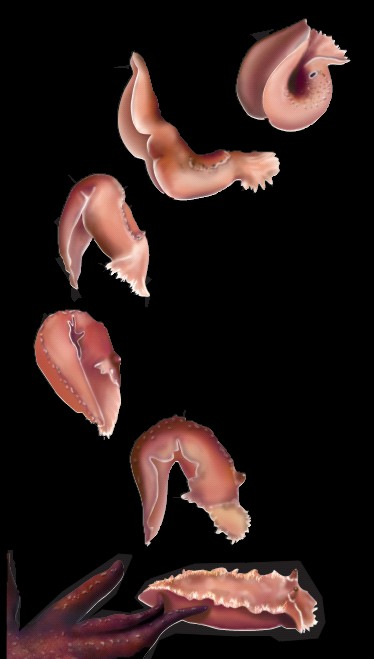

The swim CPG produces the pattern of rhythmic activity that drives the swim efferent neurons, located in the pedal ganglia, which in turn convey their pattern of activity to the muscles. The swim CPG neurons have been identified by their interconnections with each other, their ability to reset the phase of the swim rhythm, and their synaptic connections to the pedal efferent neurons.

The swim CPG is composed of three, bilaterally represented cell types: one Cerebral neuron 2, three Dorsal Swim Interneurons, and two Ventral Swim Interneurons.

The rhythmic bursting during the swim motor pattern seems to arise through conventional synaptic interactions, making the CPG a rare example of a "Network Oscillator".

[Find more about Tritonia's Swim Network here](http://www.scholarpedia.org/article/Tritonia_swim_network)

# The Model & The Math

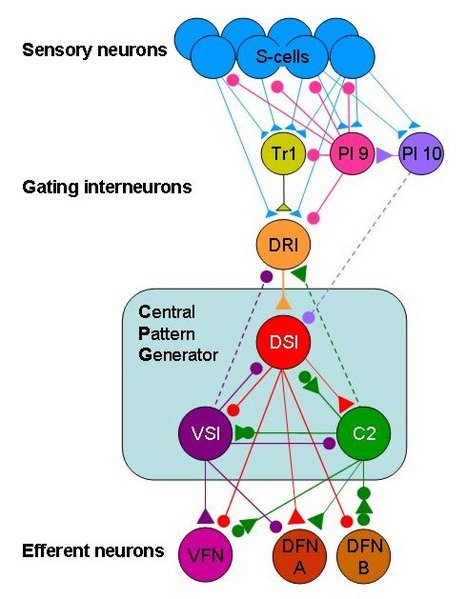

The CGP was modelled by Peter A Getting with a modified H-H model differential equations. The accomponying simulations we found in ModelDB [(GitHub Repository)](https://github.com/ModelDBRepository/93326/) were in the [NEURON](https://www.neuronsimulator.org/) language, which was quite hard to use. Hence, we created a Python program to model using the exact equations specified by Getting with Brian2.

### 1. Membrane Potential
The overall membrane potential for each neuron is governed by the standard current-balance equation:
$$C_m \frac{dV}{dt} = - I_{leak} - I_{shunt} - I_{syn} + I_{ext}$$

### 2. Leak Current (`leak.mod`)
The passive leak current is driven by the difference between the membrane potential and the resting potential:
$$I_{leak} = \frac{V - V_{rest}}{R}$$

### 3. Shunt Current (`shunt.mod`)
A voltage-dependent, non-inactivating current that acts as a dynamic shunt:
$$I_{shunt} = G \cdot m \cdot h \cdot (V - E_{rev})$$

Where the activation ($m$) and inactivation ($h$) gating variables follow standard first-order kinetics:
$$\frac{dm}{dt} = \frac{m_{\infty} - m}{\tau_m}$$
$$\frac{dh}{dt} = \frac{h_{\infty} - h}{\tau_h}$$

The steady-state functions are logistic curves:
$$m_{\infty} = \frac{1}{1 + \exp\left(\frac{V + B_m}{C_m}\right)}$$
$$h_{\infty} = \frac{1}{1 + \exp\left(\frac{V + B_h}{C_h}\right)}$$

### 4. Dynamic Threshold (`thold.mod`)
The voltage threshold for action potential generation is dynamic. It relaxes towards a steady-state value over time:
$$\frac{d\theta}{dt} = \frac{\theta_{ss} - \theta}{\tau_\theta}$$

Upon generating an action potential, the threshold undergoes an immediate, hard reset:
$$\theta \rightarrow \theta_{reset}$$

This is evaluated directly in the model as an explicit exponential decay from the time of the last spike ($t_{spike}$):
$$\theta(t) = \theta_{ss} + (\theta_{reset} - \theta_{ss}) \exp\left(-\frac{t - t_{spike}}{\tau_\theta}\right)$$

### 5. Synaptic Current (`oldtsyn.mod`)
The synaptic current combines up to three independent conductances per connection:
$$I_{syn} = \sum_{j=1}^{3} W_j \cdot G_{open, j} \cdot (V - E_{rev, j})$$

The kinetics for each conductance component ($j \in \{1,2,3\}$) model the transition from an activated state to an open state using coupled differential equations:
$$\frac{dG_{act, j}}{dt} = -\frac{G_{act, j}}{\tau_{open, j}}$$
$$\frac{dG_{open, j}}{dt} = \frac{G_{act, j}}{\tau_{open, j}} - \frac{G_{open, j}}{\tau_{close, j}}$$

Upon the arrival of a presynaptic spike, the activated state undergoes a step discontinuity:
$$G_{act, j} \rightarrow G_{act, j} + 1$$

 # Imports

In [ ]:
!pip install brian2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 16.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
from brian2 import *

# 3-cell Structure

Parameters

In [ ]:
defaultclock.dt = 0.5*ms
Cm = np.array([47.0376, 47.0376, 69.1464]) * pfarad
v_init = np.array([-40, -50, -55]) * mV
g_leak = np.array([33.33333333, 83.33333333, 66.66666667]) * nsiemens
E_leak = np.array([-40, -50, -55]) * mV
thresh_steady = np.array([-48, -30, -43]) * mV
thresh_reset  = np.array([0, -10, -30]) * mV
thresh_decay  = np.array([50, 100, 10]) * ms
G_shunt_arr = np.array([0, 0, 1.2873]) * usiemens
E_shunt_arr = np.array([0, 0, -80]) * mV
Bm_arr  = np.array([0, 0, 40.0])
Cm_sh_arr = np.array([1, 1, -5.5])
Tm_arr  = np.array([1, 1, 10]) * ms
Bh_arr  = np.array([0, 0, 68.0])
Ch_arr  = np.array([1, 1, 6.7])
Th_arr  = np.array([1, 1, 760]) * ms

Neuron Equations

In [ ]:
neuron_eqs = """
# Placeholder — integrated by custom exponential Euler in network_operation
dv/dt = 0 * volt / second : volt
dm_sh/dt = 0 / second : 1
dh_sh/dt = 0 / second : 1

# Synaptic inputs (summed from Synapses)
g_syn : siemens
i_syn_e : amp
g_syn_if : siemens
i_syn_e_if : amp

# Parameters
Cm       : farad (constant)
g_leak   : siemens (constant)
E_leak   : volt (constant)
G_shunt  : siemens (constant)
E_shunt  : volt (constant)
Bm       : 1 (constant)
Cm_sh    : 1 (constant)
tau_m_sh : second (constant)
Bh       : 1 (constant)
Ch       : 1 (constant)
tau_h_sh : second (constant)

# Dynamic threshold
v_thresh    : volt
lastspike   : second (constant)
thresh_steady : volt (constant)
thresh_reset  : volt (constant)
thresh_decay  : second (constant)
"""

neurons = NeuronGroup(3, neuron_eqs, threshold='v > v_thresh',
                      reset='lastspike = t; v_thresh = thresh_reset',
                      method='euler', name='tritonia')

neurons.Cm = Cm
neurons.g_leak = g_leak
neurons.E_leak = E_leak
neurons.v = v_init
neurons.lastspike = -1e9 * second
neurons.thresh_steady = thresh_steady
neurons.thresh_reset = thresh_reset
neurons.thresh_decay = thresh_decay
neurons.v_thresh = thresh_reset
neurons.G_shunt = G_shunt_arr
neurons.E_shunt = E_shunt_arr
neurons.Bm = Bm_arr; neurons.Cm_sh = Cm_sh_arr; neurons.tau_m_sh = Tm_arr
neurons.Bh = Bh_arr; neurons.Ch = Ch_arr; neurons.tau_h_sh = Th_arr
neurons.g_syn = 0*siemens; neurons.i_syn_e = 0*amp
neurons.g_syn_if = 0*siemens; neurons.i_syn_e_if = 0*amp
neurons.m_sh = 0.0; neurons.h_sh = 1.0


Threshold Update

In [ ]:
@network_operation(dt=defaultclock.dt, when='start', order=0)
def update_threshold():
    dt_since = defaultclock.t - neurons.lastspike
    neurons.v_thresh = (neurons.thresh_steady
                        + (neurons.thresh_reset - neurons.thresh_steady)
                        * np.exp(-dt_since / neurons.thresh_decay))

Integration - Exponential Euler (Exact, Euler & Runge Kutta fails)

In [ ]:
@network_operation(dt=defaultclock.dt, when='start', order=1)
def integrate_state():
    v  = neurons.v_[:]
    m  = neurons.m_sh_[:]
    h  = neurons.h_sh_[:]

    Cm_     = neurons.Cm_[:]
    gL      = neurons.g_leak_[:]
    EL      = neurons.E_leak_[:]
    gSh     = neurons.G_shunt_[:]
    ESh     = neurons.E_shunt_[:]
    Bm_     = neurons.Bm_[:]
    Cm_sh_  = neurons.Cm_sh_[:]
    tau_m   = neurons.tau_m_sh_[:]
    Bh_     = neurons.Bh_[:]
    Ch_     = neurons.Ch_[:]
    tau_h   = neurons.tau_h_sh_[:]
    g_syn   = neurons.g_syn_[:]
    i_syn_e = neurons.i_syn_e_[:]
    g_syn_if   = neurons.g_syn_if_[:]
    i_syn_e_if = neurons.i_syn_e_if_[:]

    dt = float(defaultclock.dt)

    # --- shunt gating (exponential Euler) ---
    # v in volts → convert to mV for the clamp formula
    vm = v / 1e-3
    xclamp = np.clip((vm + Bm_) / Cm_sh_, -100, 100)
    yclamp = np.clip((vm + Bh_) / Ch_, -100, 100)
    minf = 1.0 / (1.0 + np.exp(xclamp))
    hinf = 1.0 / (1.0 + np.exp(yclamp))

    m_new = minf + (m - minf) * np.exp(-dt / tau_m)
    h_new = hinf + (h - hinf) * np.exp(-dt / tau_h)

    # --- voltage (exponential Euler) ---
    g_shunt_eff = gSh * m_new * h_new
    g_total = gL + g_shunt_eff + g_syn + g_syn_if
    i_inj = gL * EL + g_shunt_eff * ESh + i_syn_e + i_syn_e_if

    v_inf = i_inj / g_total
    v_new = v_inf + (v - v_inf) * np.exp(-g_total * dt / Cm_)

    # write back
    neurons.m_sh_[:] = m_new
    neurons.h_sh_[:] = h_new
    neurons.v_[:] = v_new

Synapse Model

In [ ]:
syn_eqs = """
dg1_act/dt = -g1_act / tau1_open : 1 (clock-driven)
dg1_open/dt = g1_act/tau1_open - g1_open/tau1_close : 1 (clock-driven)
dg2_act/dt = -g2_act / tau2_open : 1 (clock-driven)
dg2_open/dt = g2_act/tau2_open - g2_open/tau2_close : 1 (clock-driven)
dg3_act/dt = -g3_act / tau3_open : 1 (clock-driven)
dg3_open/dt = g3_act/tau3_open - g3_open/tau3_close : 1 (clock-driven)
g_syn_post = w1*g1_open + w2*g2_open + w3*g3_open : siemens (summed)
i_syn_e_post = (w1*g1_open*e1 + w2*g2_open*e2 + w3*g3_open*e3) : amp (summed)
w1 : siemens
e1 : volt
tau1_open : second
tau1_close : second
w2 : siemens
e2 : volt
tau2_open : second
tau2_close : second
w3 : siemens
e3 : volt
tau3_open : second
tau3_close : second
"""
on_pre = "g1_act += 1; g2_act += 1; g3_act += 1"

conns = [
    (1, 0, [[0.045, 10, 400, 400],   [0.0015, -80, 400, 5000],  [0, 0, 1, 1]]),
    (2, 0, [[0.6, -80, 150, 150],    [0, 0, 1, 1],              [0, 0, 1, 1]]),
    (0, 0, [[0.001, 10, 100, 500],   [0.001, 10, 2000, 2000],   [0, 0, 1, 1]]),
    (0, 1, [[0.02, 10, 200, 800],    [0.00001, 10, 200, 2000],  [0, 0, 1, 1]]),
    (2, 1, [[0.07, -80, 400, 400],   [0.000008, -80, 400, 2000],[0, 0, 1, 1]]),
    (0, 2, [[0.003, -80, 80, 800],   [0, 0, 1, 1],              [0, 0, 1, 1]]),
    (1, 2, [[0.003, 10, 100, 1500],  [0, 0, 1, 1],              [0, 0, 1, 1]]),
    (2, 2, [[0.000025, 10, 750, 3000],[0, 0, 1, 1],             [0, 0, 1, 1]]),
    (0, 0, [[0.25, -80, 20, 20],     [0.00223, -80, 20, 5000],  [0, 0, 1, 1]]),
    (1, 1, [[0.033, -80, 40, 40],    [0.00083, -80, 40, 10000], [0, 0, 1, 1]]),
    (2, 2, [[0.08, -80, 5, 5],       [0.0075, -80, 5, 400],     [0, 0, 1, 1]]),
]

syn = Synapses(neurons, neurons, model=syn_eqs, on_pre=on_pre, method='euler')
syn.connect(i=[c[0] for c in conns], j=[c[1] for c in conns])
for k in range(3):
    setattr(syn, f'w{k+1}', np.array([c[2][k][0] for c in conns]) * usiemens)
    setattr(syn, f'e{k+1}', np.array([c[2][k][1] for c in conns]) * mV)
    setattr(syn, f'tau{k+1}_open', np.array([c[2][k][2] for c in conns]) * ms)
    setattr(syn, f'tau{k+1}_close', np.array([c[2][k][3] for c in conns]) * ms)

IF Stimulus

In [ ]:
stim_times = np.arange(5000, 6000, 100) * ms
IF = SpikeGeneratorGroup(1, [0]*len(stim_times), stim_times)

syn_if_eqs = """
dg1_act/dt = -g1_act / tau1_open : 1 (clock-driven)
dg1_open/dt = g1_act/tau1_open - g1_open/tau1_close : 1 (clock-driven)
g_syn_if_post = w1 * g1_open : siemens (summed)
i_syn_e_if_post = w1 * g1_open * e1 : amp (summed)
w1 : siemens
e1 : volt
tau1_open : second
tau1_close : second
"""
syn_if = Synapses(IF, neurons, model=syn_if_eqs, on_pre='g1_act += 1', method='euler')
syn_if.connect(i=0, j=0)
syn_if.w1 = 0.012*usiemens; syn_if.e1 = 10*mV
syn_if.tau1_open = 25*ms; syn_if.tau1_close = 15000*ms

Recording

In [ ]:
spikes = SpikeMonitor(neurons)

# Manual voltage recording (StateMonitor crashes with manual v_ updates)
v_rec = [[] for _ in range(3)]
vth_rec = [[] for _ in range(3)]
t_rec = []

@network_operation(dt=defaultclock.dt, when='start', order=2)
def record_voltage():
    t_rec.append(float(defaultclock.t/ms))
    for i in range(3):
        v_rec[i].append(float(neurons.v_[i]/mV))
        vth_rec[i].append(float(neurons.v_thresh_[i]/mV))

Run & Report

The results are stored in a .npz file that can be rendered using Numpy and plotted with Matplotlib

In [ ]:
run(6000*ms, report='text')
import sys
t_arr = np.array(t_rec)
si = np.asarray(spikes.i)
st = np.asarray(spikes.t)
with open('tritonia_summary.txt', 'w') as f:
    f.write(f"Total spikes: {len(si)}\n")
    for i, name in enumerate(['DSI', 'C2', 'VSI']):
        mask = (si == i)
        f.write(f"{name}: {np.sum(mask)} spikes\n")

np.savez('tritonia_results.npz',
         spike_i=si, spike_t=st/second,
         v_t=t_arr, v_dsi=v_rec[0], v_c2=v_rec[1], v_vsi=v_rec[2],
         vth_dsi=vth_rec[0], vth_c2=vth_rec[1], vth_vsi=vth_rec[2])
sys.stdout.flush()
sys.exit(0)

WARNING    'thresh_reset' is an internal variable of group 'tritonia', but also exists in the run namespace with the value array([  0., -10., -30.]) * mvolt. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Starting simulation at t=0. s for a duration of 6. s
2.6495 s (44%) simulated in 10s, estimated 13s remaining.
5.375 s (89%) simulated in 20s, estimated 2s remaining.
6. s (100%) simulated in 22s


SystemExit: 0

WARNING    /usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
 [py.warnings]
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)

